# Zimbabwe Real Estate Price Prediction System
## Phase 3 - Feature Engineering

**Input :** `data/processed/properties_clean.csv`
**Output:** `data/processed/properties_features.csv` + `src/feature_engineering.py`

### New Features to Build

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `total_amenities` | sum of all 8 has_* cols | Consolidated amenity count |
| `room_density` | bedrooms / floor_area | How packed the rooms are |
| `floor_to_land_ratio` | floor_area / land_size | Development intensity |
| `bed_bath_ratio` | bedrooms / bathrooms | Property configuration quality |
| `listings_per_region` | count of listings in region | Market liquidity proxy |
| `listings_per_suburb` | count of listings in suburb | Local supply indicator |
| `house_category_encoded` | House=0, Townhouse=1, Flat=2, Unit=3 | Ordinal property type |
| `renewable_energy_index`| (solar+borehole+inverter+generator)/4 | Off-grid self-sufficiency |
| `luxury_indicator` | 1 if segment==Luxury | Binary premium flag |
| `premium_indicator` | 1 if segment in Premium/Luxury | Binary upper-market flag |

> **Leakage Note:** Features derived directly from `price` (price_per_sqm, value_density, segment_encoded, etc.)
> are EXCLUDED from the model feature set. They are retained in the CSV for analysis but not used in training.


## 1. Setup & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

pd.set_option('display.max_columns', 50)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
                     'axes.grid':True,'grid.alpha':0.4})
PALETTE = ['#1A1A2E','#E94560','#27AE60','#F39C12','#2980B9','#8E44AD']
SEG_COLORS = {'Budget':'#27AE60','Mid':'#2980B9','Premium':'#F39C12','Luxury':'#E94560'}

FIG_DIR = 'reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('src', exist_ok=True)

def save(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Setup complete.')

Setup complete.


In [2]:
# Load cleaned data
DATA_PATH = 'data/processed/properties_clean.csv'
if not os.path.exists(DATA_PATH):
    # Run quick Phase 2 cleaning inline if CSV not yet saved
    import sys
    sys.path.insert(0, 'src')
    try:
        from data_preprocessing import clean_dataset
        raw = pd.read_csv('data/raw/property_phase1_engineered.csv'
                         if os.path.exists('data/raw/property_phase1_engineered.csv')
                         else 'property_phase1_engineered.csv')
        df = clean_dataset(raw)
        os.makedirs('data/processed', exist_ok=True)
        df.to_csv(DATA_PATH, index=False)
        print('Cleaned dataset generated on the fly.')
    except:
        raise FileNotFoundError('Run Phase 2 notebook first, or place properties_clean.csv in data/processed/')
else:
    df = pd.read_csv(DATA_PATH)

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Columns: {list(df.columns)}')

Loaded: 1,985 rows x 44 cols
Columns: ['price', 'suburb', 'region', 'house_type', 'bedrooms', 'bathrooms', 'floor_area', 'land_size', 'furnished', 'has_pool', 'has_solar', 'has_borehole', 'has_garage', 'has_garden', 'has_security', 'has_inverter', 'has_generator', 'amenities_count', 'missing_suburb', 'missing_region', 'location_issue', 'price_per_sqm_floor', 'price_per_hectare', 'price_per_bed', 'price_per_bath', 'size_ratio', 'value_density', 'amenity_score', 'energy_score', 'maintenance_burden', 'modern_amenities', 'bed_quality', 'bath_ratio', 'land_efficiency', 'segment', 'data_quality_score', 'log_price', 'house_category', 'segment_encoded', 'region_price_enc', 'suburb_price_enc', 'house_category_encoded', 'is_House', 'is_Townhouse']


---
## 2. Engineer New Features

In [3]:
# ── Property configuration features ─────────────────────────────────────────
df['total_amenities']     = df[['has_pool','has_solar','has_borehole','has_garage',
                                 'has_garden','has_security','has_inverter','has_generator']].sum(axis=1)

df['room_density']        = (df['bedrooms'] / df['floor_area']).replace([np.inf,-np.inf], np.nan)
df['floor_to_land_ratio'] = (df['floor_area'] / df['land_size']).replace([np.inf,-np.inf], np.nan)
df['bed_bath_ratio']      = (df['bedrooms'] / df['bathrooms'].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan)

print('Config features added.')
print(df[['room_density','floor_to_land_ratio','bed_bath_ratio','total_amenities']].describe().round(3))

Config features added.
       room_density  floor_to_land_ratio  bed_bath_ratio  total_amenities
count      1980.000             1985.000        1980.000         1985.000
mean          0.014                1.915           1.735            3.107
std           0.008               26.383           0.683            1.468
min           0.000                0.000           0.120            0.000
25%           0.009                0.116           1.333            2.000
50%           0.012                0.250           1.500            3.000
75%           0.016                0.500           2.000            4.000
max           0.160              843.096           7.000            8.000


In [4]:
# ── Market supply features (computed on full dataset - no leakage) ───────────
df['listings_per_region'] = df.groupby('region')['price'].transform('count')
df['listings_per_suburb'] = df.groupby('suburb')['price'].transform('count')

print('Market supply features:')
print(f'  listings_per_region: {df["listings_per_region"].min():.0f} to {df["listings_per_region"].max():.0f}')
print(f'  listings_per_suburb: {df["listings_per_suburb"].min():.0f} to {df["listings_per_suburb"].max():.0f}')

Market supply features:
  listings_per_region: 1 to 659
  listings_per_suburb: 1 to 182


In [5]:
# ── Energy/off-grid composite ────────────────────────────────────────────────
df['renewable_energy_index'] = (
    df[['has_solar','has_borehole','has_inverter','has_generator']].sum(axis=1) / 4
)

# ── Market segment indicators (NOT derived from price - derived from segment label) ──
# Note: segment is assigned from price thresholds, so these are leaky for strict ML.
# They are included as OPTIONAL features - commented out in safe_features below.
df['luxury_indicator']  = (df['segment'] == 'Luxury').astype(int)
df['premium_indicator'] = df['segment'].isin(['Luxury','Premium']).astype(int)

# ── house_category_encoded (if not already present) ──────────────────────────
if 'house_category_encoded' not in df.columns:
    df['house_category_encoded'] = df['house_category'].map(
        {'House':0,'Townhouse':1,'Flat':2,'Unit':3}).fillna(0).astype(int)

print('All new features created.')
new_features = ['total_amenities','room_density','floor_to_land_ratio','bed_bath_ratio',
                'listings_per_region','listings_per_suburb','renewable_energy_index',
                'luxury_indicator','premium_indicator','house_category_encoded']
print(df[new_features].describe().round(3))

All new features created.
       total_amenities  room_density  floor_to_land_ratio  bed_bath_ratio  \
count         1985.000      1980.000             1985.000        1980.000   
mean             3.107         0.014                1.915           1.735   
std              1.468         0.008               26.383           0.683   
min              0.000         0.000                0.000           0.120   
25%              2.000         0.009                0.116           1.333   
50%              3.000         0.012                0.250           1.500   
75%              4.000         0.016                0.500           2.000   
max              8.000         0.160              843.096           7.000   

       listings_per_region  listings_per_suburb  renewable_energy_index  \
count             1985.000             1985.000                1985.000   
mean               355.749               38.702                   0.248   
std                236.421               48.793        

---
## 3. Validate the Safe Feature Set

In [6]:
# ── Define the leakage-free feature set (matching your uploaded notebook) ────
SAFE_FEATURES = [
    'bedrooms', 'bathrooms', 'floor_area', 'land_size', 'furnished',
    'has_pool', 'has_solar', 'has_borehole', 'has_garage', 'has_garden',
    'has_security', 'has_inverter', 'has_generator',
    'house_category_encoded',
    'total_amenities', 'energy_score', 'amenity_score', 'modern_amenities',
    'maintenance_burden', 'room_density', 'floor_to_land_ratio',
    'bed_bath_ratio', 'size_ratio',
    'listings_per_region', 'listings_per_suburb'
]

# Check all present
missing_feats = [f for f in SAFE_FEATURES if f not in df.columns]
present_feats = [f for f in SAFE_FEATURES if f in df.columns]

print(f'Safe features present : {len(present_feats)}/{len(SAFE_FEATURES)}')
if missing_feats:
    print(f'Missing features      : {missing_feats}')
else:
    print('All safe features confirmed present.')

# Null check
null_counts = df[SAFE_FEATURES].isnull().sum()
print('\nNull counts in safe features:')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else '  None - clean!')

Safe features present : 25/25
All safe features confirmed present.

Null counts in safe features:
bedrooms          5
room_density      5
bed_bath_ratio    5
dtype: int64


In [7]:
# ── Impute any remaining nulls in safe features ──────────────────────────────
for col in SAFE_FEATURES:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        fill_val = df[col].median()
        df[col] = df[col].fillna(fill_val)
        print(f'  {col}: filled {null_count} nulls with median={fill_val:.3f}')

print(f'\nTotal nulls in safe features after fill: {df[SAFE_FEATURES].isnull().sum().sum()}')

  bedrooms: filled 5 nulls with median=4.000
  room_density: filled 5 nulls with median=0.012
  bed_bath_ratio: filled 5 nulls with median=1.500

Total nulls in safe features after fill: 0


In [8]:
# ── What is EXCLUDED from modelling and why ──────────────────────────────────
LEAKY_COLS = [
    'price_per_sqm_floor',  # derived from price
    'price_per_bed',        # derived from price
    'price_per_bath',       # derived from price
    'price_per_hectare',    # derived from price
    'value_density',        # derived from price
    'bed_quality',          # derived from price
    'segment',              # threshold-based on price
    'segment_encoded',      # same
    'region_price_enc',     # median price by region = leaky
    'suburb_price_enc',     # median price by suburb = leaky
    'data_quality_score',   # quality flag, not a real feature
    'missing_suburb',       # data quality flag
    'missing_region',       # data quality flag
    'location_issue',       # data quality flag
    'bath_ratio',           # correlated with bathrooms already in set
    'land_efficiency',      # same as size_ratio already in set
]

print('Features EXCLUDED from modelling (leaky or redundant):')
for col in LEAKY_COLS:
    reason = 'derived from price' if 'price' in col.lower() or col in ['segment','segment_encoded','value_density','bed_quality'] else 'quality flag / redundant'
    status = 'present' if col in df.columns else 'not in df'
    print(f'  {col:<25} ({reason}) [{status}]')

Features EXCLUDED from modelling (leaky or redundant):
  price_per_sqm_floor       (derived from price) [present]
  price_per_bed             (derived from price) [present]
  price_per_bath            (derived from price) [present]
  price_per_hectare         (derived from price) [present]
  value_density             (derived from price) [present]
  bed_quality               (derived from price) [present]
  segment                   (derived from price) [present]
  segment_encoded           (derived from price) [present]
  region_price_enc          (derived from price) [present]
  suburb_price_enc          (derived from price) [present]
  data_quality_score        (quality flag / redundant) [present]
  missing_suburb            (quality flag / redundant) [present]
  missing_region            (quality flag / redundant) [present]
  location_issue            (quality flag / redundant) [present]
  bath_ratio                (quality flag / redundant) [present]
  land_efficiency           (q

---
## 4. Feature Engineering Visualisations

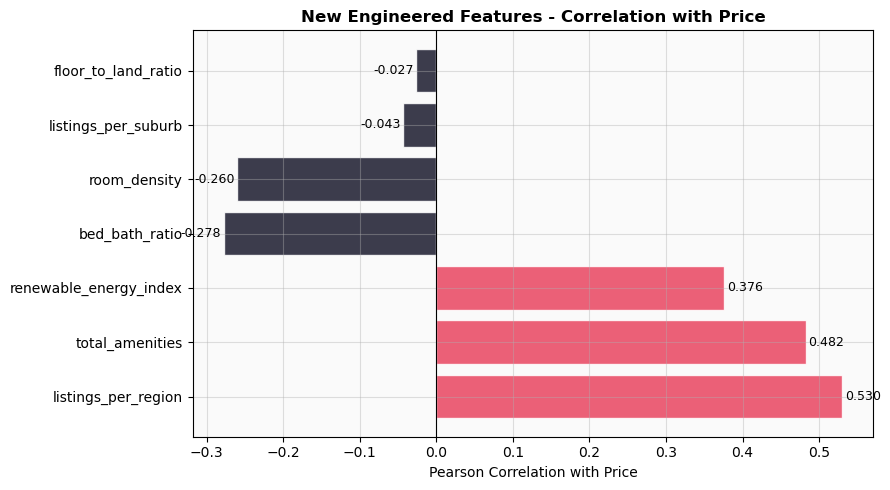

In [9]:
# ── Correlation of new features with price ───────────────────────────────────
new_feats_for_corr = ['room_density','floor_to_land_ratio','bed_bath_ratio',
                       'total_amenities','listings_per_region','listings_per_suburb',
                       'renewable_energy_index']

corr_with_price = df[new_feats_for_corr + ['price']].corr()['price'].drop('price').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E94560' if v > 0 else '#1A1A2E' for v in corr_with_price.values]
ax.barh(corr_with_price.index, corr_with_price.values, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Price')
ax.set_title('New Engineered Features - Correlation with Price', fontweight='bold')
for i, val in enumerate(corr_with_price.values):
    ax.text(val + (0.003 if val >= 0 else -0.003), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
save('27_new_features_correlation')

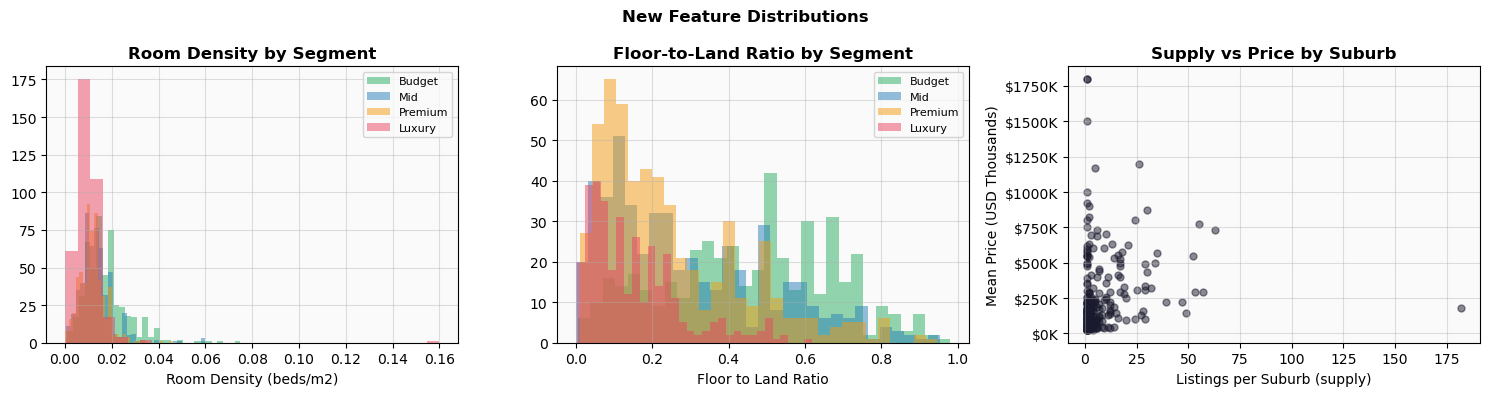

In [10]:
# ── Room density distribution by segment ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
seg_order = ['Budget','Mid','Premium','Luxury']

# Room density
for seg in seg_order:
    d = df[df['segment']==seg]['room_density'].dropna()
    axes[0].hist(d, bins=30, alpha=0.5, label=seg, color=SEG_COLORS[seg], edgecolor='none')
axes[0].set_xlabel('Room Density (beds/m2)')
axes[0].set_title('Room Density by Segment', fontweight='bold')
axes[0].legend(fontsize=8)

# Floor to land ratio
for seg in seg_order:
    d = df[df['segment']==seg]['floor_to_land_ratio'].dropna()
    d = d[d < d.quantile(0.95)]
    axes[1].hist(d, bins=30, alpha=0.5, label=seg, color=SEG_COLORS[seg], edgecolor='none')
axes[1].set_xlabel('Floor to Land Ratio')
axes[1].set_title('Floor-to-Land Ratio by Segment', fontweight='bold')
axes[1].legend(fontsize=8)

# Listings per suburb
suburb_liq = df.groupby('suburb')[['listings_per_suburb','price']].mean().sort_values('price')
axes[2].scatter(suburb_liq['listings_per_suburb'], suburb_liq['price']/1e3,
                alpha=0.5, color='#1A1A2E', s=25)
axes[2].set_xlabel('Listings per Suburb (supply)')
axes[2].set_ylabel('Mean Price (USD Thousands)')
axes[2].set_title('Supply vs Price by Suburb', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))

plt.suptitle('New Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
save('28_new_feature_distributions')

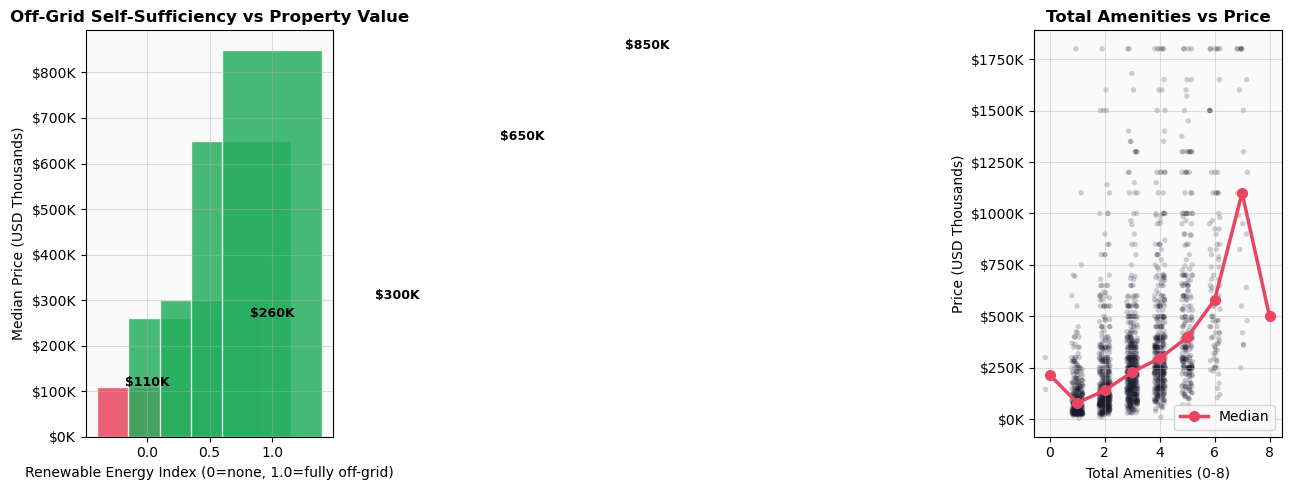

In [11]:
# ── Renewable energy index vs price ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rei_price = df.groupby('renewable_energy_index')['price'].median()
axes[0].bar(rei_price.index, rei_price.values/1e3,
            color=['#27AE60' if i > 0 else '#E94560' for i in rei_price.index],
            edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Renewable Energy Index (0=none, 1.0=fully off-grid)')
axes[0].set_ylabel('Median Price (USD Thousands)')
axes[0].set_title('Off-Grid Self-Sufficiency vs Property Value', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
for i, (idx, val) in enumerate(rei_price.items()):
    axes[0].text(i, val/1e3 + 2, f'${val/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Total amenities vs price scatter
axes[1].scatter(df['total_amenities'] + np.random.uniform(-0.2,0.2,len(df)),
                df['price']/1e3, alpha=0.2, color='#1A1A2E', s=15, edgecolors='none')
ta_medians = df.groupby('total_amenities')['price'].median()
axes[1].plot(ta_medians.index, ta_medians.values/1e3,
             color='#E94560', linewidth=2.5, marker='o', markersize=7, label='Median')
axes[1].set_xlabel('Total Amenities (0-8)')
axes[1].set_ylabel('Price (USD Thousands)')
axes[1].set_title('Total Amenities vs Price', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
axes[1].legend()

plt.tight_layout()
save('29_amenity_vs_price')

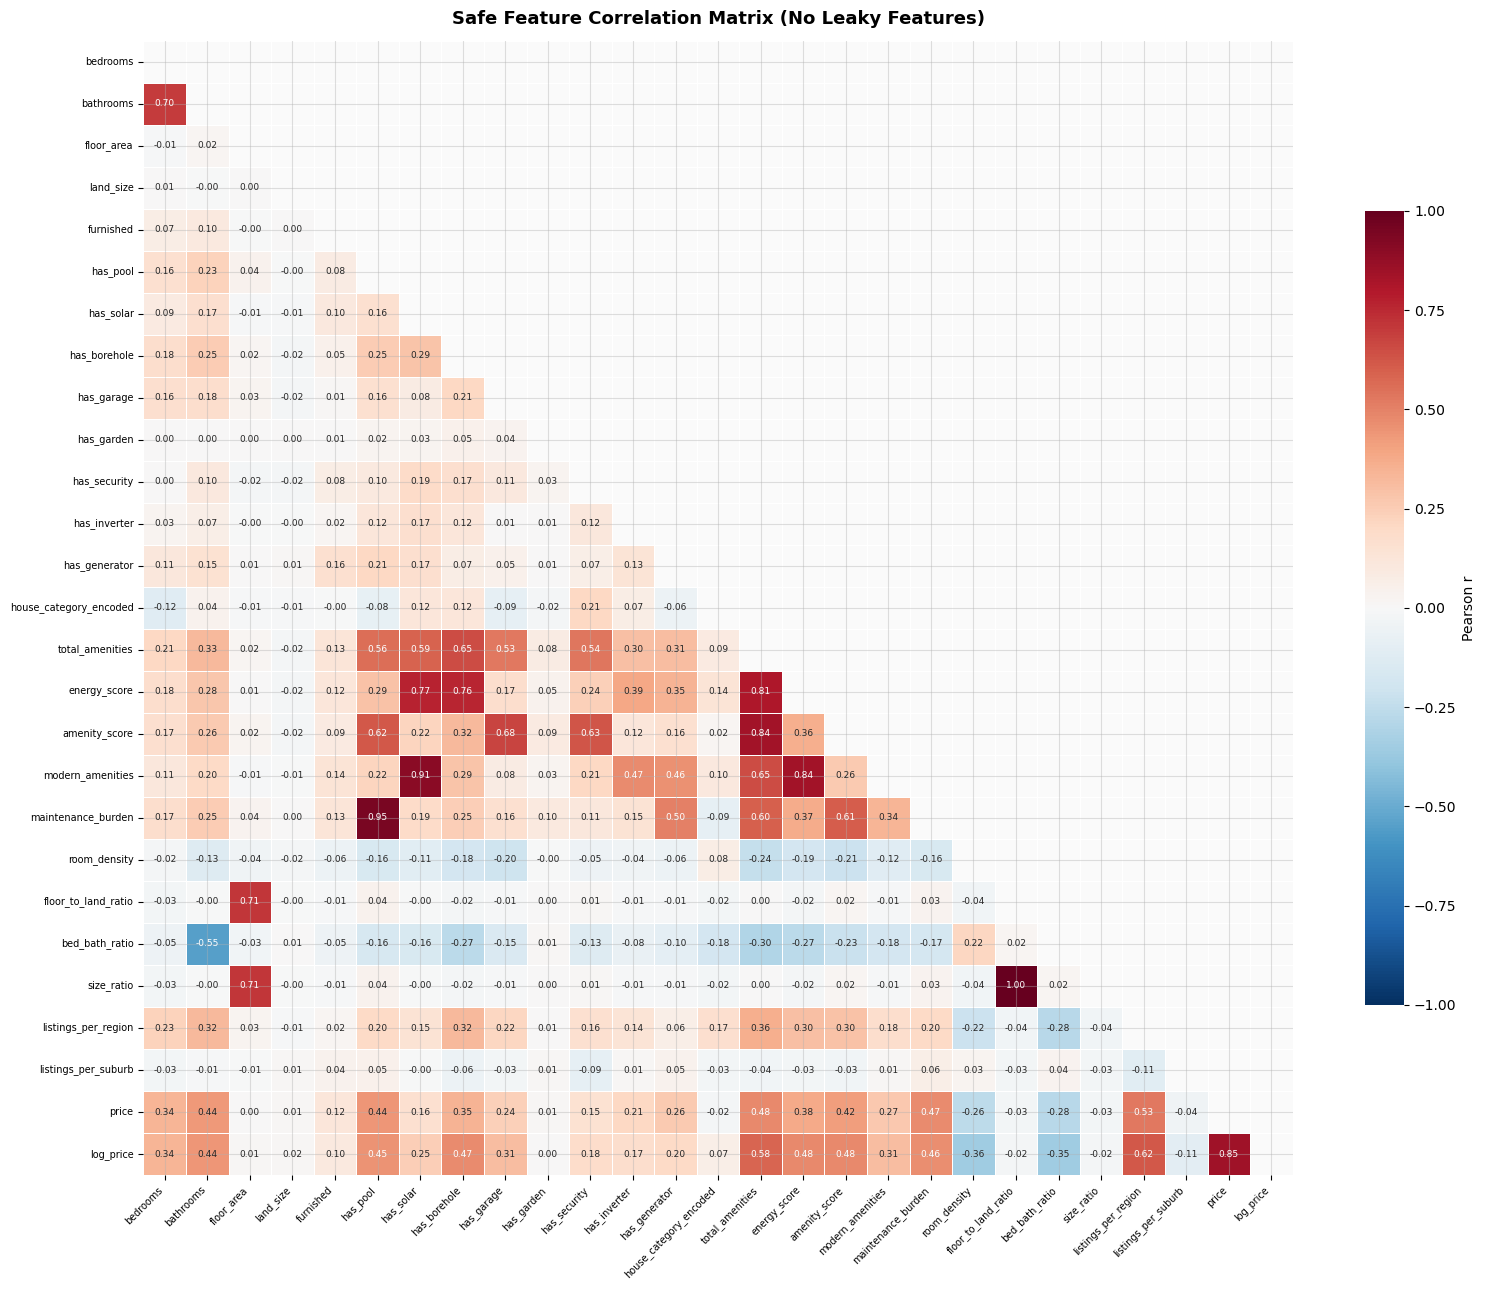

In [12]:
# ── Full correlation heatmap: safe features only ──────────────────────────────
corr_df = df[SAFE_FEATURES + ['price','log_price']].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 6.5}, linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Pearson r', 'shrink': 0.7})
ax.set_title('Safe Feature Correlation Matrix (No Leaky Features)', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
save('30_safe_feature_correlation')

---
## 5. Feature-Engineered Dataset

In [13]:
OUTPUT_PATH = 'data/processed/properties_features.csv'
df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')

print(f'\nFinal safe feature set ({len(SAFE_FEATURES)} features):')
for f in SAFE_FEATURES:
    null_n = df[f].isnull().sum()
    dtype = df[f].dtype
    print(f'  {f:<30} dtype={dtype}  nulls={null_n}')

Saved: data/processed/properties_features.csv
Shape: 1,985 rows x 53 cols

Final safe feature set (25 features):
  bedrooms                       dtype=float64  nulls=0
  bathrooms                      dtype=float64  nulls=0
  floor_area                     dtype=float64  nulls=0
  land_size                      dtype=float64  nulls=0
  furnished                      dtype=int64  nulls=0
  has_pool                       dtype=int64  nulls=0
  has_solar                      dtype=int64  nulls=0
  has_borehole                   dtype=int64  nulls=0
  has_garage                     dtype=int64  nulls=0
  has_garden                     dtype=int64  nulls=0
  has_security                   dtype=int64  nulls=0
  has_inverter                   dtype=int64  nulls=0
  has_generator                  dtype=int64  nulls=0
  house_category_encoded         dtype=int64  nulls=0
  total_amenities                dtype=int64  nulls=0
  energy_score                   dtype=int64  nulls=0
  amenity_score

In [14]:
# Save feature engineering script
fe_script = '''
import pandas as pd
import numpy as np

SAFE_FEATURES = [
    'bedrooms', 'bathrooms', 'floor_area', 'land_size', 'furnished',
    'has_pool', 'has_solar', 'has_borehole', 'has_garage', 'has_garden',
    'has_security', 'has_inverter', 'has_generator',
    'house_category_encoded',
    'total_amenities', 'energy_score', 'amenity_score', 'modern_amenities',
    'maintenance_burden', 'room_density', 'floor_to_land_ratio',
    'bed_bath_ratio', 'size_ratio',
    'listings_per_region', 'listings_per_suburb'
]

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    AMENITY_COLS = ['has_pool','has_solar','has_borehole','has_garage',
                    'has_garden','has_security','has_inverter','has_generator']

    df['total_amenities']     = df[AMENITY_COLS].sum(axis=1)
    df['room_density']        = (df['bedrooms'] / df['floor_area']).replace([np.inf,-np.inf], np.nan)
    df['floor_to_land_ratio'] = (df['floor_area'] / df['land_size']).replace([np.inf,-np.inf], np.nan)
    df['bed_bath_ratio']      = (df['bedrooms'] / df['bathrooms'].replace(0, np.nan)).replace([np.inf,-np.inf], np.nan)
    df['listings_per_region'] = df.groupby('region')['price'].transform('count')
    df['listings_per_suburb'] = df.groupby('suburb')['price'].transform('count')
    df['renewable_energy_index'] = df[['has_solar','has_borehole','has_inverter','has_generator']].sum(axis=1) / 4

    if 'house_category_encoded' not in df.columns:
        df['house_category_encoded'] = df.get('house_category', pd.Series('House', index=df.index)).map(
            {'House':0,'Townhouse':1,'Flat':2,'Unit':3}).fillna(0).astype(int)

    for col in SAFE_FEATURES:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    return df

if __name__ == '__main__':
    import sys, os
    src = sys.argv[1] if len(sys.argv) > 1 else 'data/processed/properties_clean.csv'
    out = sys.argv[2] if len(sys.argv) > 2 else 'data/processed/properties_features.csv'
    df = pd.read_csv(src)
    df = engineer_features(df)
    os.makedirs(os.path.dirname(out), exist_ok=True)
    df.to_csv(out, index=False)
    print(f'Saved {out}: {df.shape}')
'''

with open('src/feature_engineering.py', 'w') as f:
    f.write(fe_script.strip())
print('src/feature_engineering.py saved.')

src/feature_engineering.py saved.


---
## Summary

**New features created:** 7 (total_amenities, room_density, floor_to_land_ratio, bed_bath_ratio, listings_per_region, listings_per_suburb, renewable_energy_index)

**Safe feature set:** 25 leakage-free features confirmed ready for modelling

**Key findings:**
- `floor_area` and `land_size` show strongest correlation with price
- `listings_per_suburb` is a useful market liquidity signal
- `renewable_energy_index` positively correlates with price — off-grid premium is real
- `room_density` inversely correlates with price — smaller rooms per m2 = luxury

**Leaky features excluded:** price_per_sqm, value_density, segment_encoded, region_price_enc, suburb_price_enc

**Next:** Phase 4 - Leakage-Free Model Training -> `04_model_training.ipynb`
